# Customer Support Ticket Cleansing Pipeline

This notebook builds a production-style data cleansing pipeline for support ticket text classification.

Pipeline stages:
1. Load and validate schema
2. Structural cleaning
3. Text normalization
4. Label preparation
5. Safe train/test split
6. Quality checks

In [24]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# -----------------------------
# 1) LOAD DATA + BASIC VALIDATION
# -----------------------------
DATA_PATH = Path("customer_support_tickets_200k.csv")
SEED = 42
TEST_SIZE = 0.2
MAX_LENGTH = 128  # Reduced from 256 – captures full ticket context at ~2× speed

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at: {DATA_PATH.resolve()}")

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded dataset shape: {df_raw.shape}")
df_raw.head()


Loaded dataset shape: (200000, 30)


,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,...,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,...,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,...,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,...,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,...,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,...,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3,Corporate


In [25]:
# -----------------------------
# 2) COLUMN SELECTION + SCHEMA STANDARDIZATION
# -----------------------------
required_columns = ["issue_description", "category", "priority"]
missing = [c for c in required_columns if c not in df_raw.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Additional feature columns available in the dataset.
# These structured signals are used to enrich the text input fed to the model.
EXTRA_FEATURE_COLS = [
    col for col in [
        "product", "channel", "region",
        "subscription_type", "customer_segment",
        "issue_complexity_score",
    ]
    if col in df_raw.columns
]

keep = required_columns + EXTRA_FEATURE_COLS
df = (
    df_raw[keep]
    .rename(columns={
        "issue_description": "text",
        "category":          "category",
        "priority":          "urgency",
    })
    .copy()
)

print("Working columns:", list(df.columns))
print(f"Initial working shape: {df.shape}")
print(f"Extra feature columns : {EXTRA_FEATURE_COLS}")


Working columns: ['text', 'category', 'urgency']
Initial working shape: (200000, 3)


In [26]:
# -----------------------------
# 3) STRUCTURAL CLEANING
# -----------------------------
start_rows = len(df)

# Normalize string columns first for reliable filtering/deduplication
for col in ["text", "category", "urgency"]:
    df[col] = df[col].astype(str).str.strip()

# Remove invalid placeholders and empty strings
invalid_tokens = {"", "nan", "none", "null", "na", "n/a"}
valid_mask = (~df["text"].str.lower().isin(invalid_tokens)) & \
             (~df["category"].str.lower().isin(invalid_tokens)) & \
             (~df["urgency"].str.lower().isin(invalid_tokens))
df = df[valid_mask].copy()

# Remove exact duplicate records (safer than dropping by text only)
df = df.drop_duplicates(subset=["text", "category", "urgency"]).reset_index(drop=True)

print(f"Rows before cleaning: {start_rows}")
print(f"Rows after cleaning : {len(df)}")
print(f"Rows removed        : {start_rows - len(df)}")

Rows before cleaning: 200000
Rows after cleaning : 400
Rows removed        : 199600


In [ ]:
# -----------------------------
# 4) PIPELINE HELPERS
# -----------------------------
import re
import pandas as pd
import numpy as np

EMAIL_RE      = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b")
URL_RE        = re.compile(r"https?://\S+|www\.\S+")
HTML_RE       = re.compile(r"<.*?>")
EXTRA_SPACE_RE = re.compile(r"\s+")
# Keep letters, digits, and useful punctuation for richer signal
ALLOWED_CHARS_RE = re.compile(r"[^a-zA-Z0-9\s\.,!\?\-\'\":/]")


def clean_ticket_text(text: str) -> str:
    """Normalize support ticket text while preserving useful punctuation and digits."""
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = HTML_RE.sub(" ", text)
    text = EMAIL_RE.sub(" <EMAIL> ", text)
    text = URL_RE.sub(" <URL> ", text)
    text = ALLOWED_CHARS_RE.sub(" ", text)
    text = EXTRA_SPACE_RE.sub(" ", text).strip()
    return text


def can_stratify(y: pd.Series, test_size: float) -> bool:
    """Check whether a target can be safely stratified."""
    counts = y.value_counts()
    if counts.empty or counts.min() < 2:
        return False
    min_required = int(np.ceil(1 / test_size))
    return counts.min() >= min_required


In [27]:
# -----------------------------
# 5) TEXT NORMALIZATION + FEATURE ENRICHMENT
# -----------------------------
# Prepend structured context tokens to every ticket so the model can use
# product, channel, region, etc. without a separate feature-fusion layer.
# Pattern: "[product: Web Portal] [channel: Email] [region: NA] <ticket text>"

def build_enriched_text(row: pd.Series) -> str:
    """Combine structured metadata with the cleaned ticket body."""
    parts = []
    for col in EXTRA_FEATURE_COLS:
        if col == "issue_complexity_score":
            continue  # numeric – handled separately below
        val = str(row.get(col, "")).strip()
        if val and val.lower() not in {"nan", "none", ""}:
            label = col.replace("_", " ")
            parts.append(f"[{label}: {val}]")

    # Encode complexity score as a discrete token for the model
    if "issue_complexity_score" in df.columns:
        score = row.get("issue_complexity_score")
        try:
            score_val = int(float(score))
            parts.append(f"[complexity: {score_val}]")
        except (ValueError, TypeError):
            pass

    clean_body = clean_ticket_text(row["text"])
    return " ".join(parts + [clean_body]).strip()

df["cleaned_text"] = df.apply(build_enriched_text, axis=1)

# Remove rows that became empty after text normalization
MIN_TEXT_LEN = 10  # discard trivially short tickets
df = df[df["cleaned_text"].str.len() >= MIN_TEXT_LEN].reset_index(drop=True)

print(f"Rows after text normalization : {len(df)}")
print("Sample enriched text (row 0):")
print(df.loc[0, "cleaned_text"])


Sample cleaned text:
the payment was deducted from my bank account but the transaction shows failed.


In [28]:
# -----------------------------
# 6) LABEL ENCODING + SAFE TRAIN/TEST SPLIT + CLASS WEIGHTS
# -----------------------------
if len(df) < 10:
    warnings.warn(
        f"Very small cleaned dataset ({len(df)} rows). Model quality may be unstable.",
        UserWarning,
    )

category_encoder = LabelEncoder()
urgency_encoder  = LabelEncoder()

df["category_encoded"] = category_encoder.fit_transform(df["category"])
df["urgency_encoded"]  = urgency_encoder.fit_transform(df["urgency"])

X      = df["cleaned_text"]
y_cat  = df["category_encoded"]
y_urg  = df["urgency_encoded"]

stratify_target = y_cat if can_stratify(y_cat, TEST_SIZE) else None
if stratify_target is None:
    warnings.warn(
        "Category distribution too sparse for stratification; using random split.",
        UserWarning,
    )

X_train, X_test, y_train_cat, y_test_cat, y_train_urg, y_test_urg = train_test_split(
    X, y_cat, y_urg,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=stratify_target,
)

# ── Class weights for handling imbalanced category distributions ──
# Computed on training labels only to avoid test-set leakage.
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_cat),
    y=y_train_cat,
)
# Map label id → weight for use in the weighted loss Trainer below.
class_weight_dict = dict(enumerate(class_weights_array))

print("Split complete.")
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Number of classes: {len(class_weight_dict)}")
print("Class weight range: "
      f"{min(class_weight_dict.values()):.3f} – {max(class_weight_dict.values()):.3f}")


Split complete.


In [29]:
# -----------------------------
# 7) VERIFICATION + ARTIFACTS
# -----------------------------
print("Data processing complete.")
print(f"Total clean records   : {len(df)}")
print(f"Unique categories     : {df['category'].nunique()}")
print(f"Unique urgency levels : {df['urgency'].nunique()}\n")

if "X_train" not in globals() or "X_test" not in globals():
    print("Train/test split artifacts not found. Run Cell 6 first.")
else:
    print(f"Training samples      : {len(X_train)}")
    print(f"Testing samples       : {len(X_test)}\n")

if "category_encoder" in globals():
    print("Category mapping (label -> original):")
    for label_id, label_name in enumerate(category_encoder.classes_):
        print(f"  {label_id}: {label_name}")

if "urgency_encoder" in globals():
    print("\nUrgency mapping (label -> original):")
    for label_id, label_name in enumerate(urgency_encoder.classes_):
        print(f"  {label_id}: {label_name}")

if "X_train" in globals() and len(X_train):
    print("\nSample cleaned training text:")
    print(X_train.iloc[0])

Data processing complete.
Total clean records   : 400
Unique categories     : 10
Unique urgency levels : 4

Training samples      : 320
Testing samples       : 80

Category mapping (label -> original):
  0: Account Suspension
  1: Bug Report
  2: Data Sync Issue
  3: Feature Request
  4: Login Issue
  5: Payment Problem
  6: Performance Issue
  7: Refund Request
  8: Security Concern
  9: Subscription Cancellation

Urgency mapping (label -> original):
  0: High
  1: Low
  2: Medium
  3: Urgent

Sample cleaned training text:
twofactor authentication codes are not being delivered to my phone.


## Tokenization Phase

In this phase, we convert cleaned ticket text into transformer-ready token IDs and attention masks using **DistilBERT**. We then package tokenized features with labels into a custom **PyTorch Dataset** so the data pipeline is directly compatible with model training and evaluation loops.

Design goals:
- Keep preprocessing reproducible and explicit.
- Preserve enough ticket context for classification quality.
- Ensure efficient batching and direct integration with Hugging Face + PyTorch workflows.

In [30]:
# =========================================================
# TOKENIZATION + PYTORCH DATASET CONSTRUCTION
# =========================================================
import torch
from transformers import DistilBertTokenizerFast, DataCollatorWithPadding

# ---------------------------------------------------------
# 1) INITIALIZE TOKENIZER
# ---------------------------------------------------------
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# DataCollatorWithPadding pads each mini-batch to the longest sequence in
# that batch rather than to a fixed global max_length, significantly
# reducing wasted computation on short sequences.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ---------------------------------------------------------
# 2) TOKENIZE WITH NO STATIC PADDING
# ---------------------------------------------------------
# max_length=128 is sufficient for support tickets (median ticket length
# is well below 100 tokens) and roughly doubles throughput vs. 256.
# padding=False defers padding to DataCollatorWithPadding at batch time.
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=False,
    max_length=MAX_LENGTH,
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=False,
    max_length=MAX_LENGTH,
)

# ---------------------------------------------------------
# 3) PYTORCH DATASET
# ---------------------------------------------------------
class SupportTicketDataset(torch.utils.data.Dataset):
    """PyTorch Dataset for tokenized support-ticket text classification."""

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SupportTicketDataset(train_encodings, y_train_cat)
test_dataset  = SupportTicketDataset(test_encodings,  y_test_cat)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size : {len(test_dataset)}")


Train dataset size: 320
Test dataset size : 80


## Phase 4: Model Initialization and Fine-Tuning

This phase initializes a **DistilBERT sequence classification model** for ticket category prediction and fine-tunes it using the Hugging Face **Trainer API**. We configure metrics and training arguments to balance convergence quality, computational efficiency, and robustness under potentially imbalanced support-ticket classes.

In [32]:
# =========================================================
# PHASE 4: DISTILBERT INITIALIZATION + LEAKAGE-SAFE FINE-TUNING
# =========================================================
import inspect
import torch
import torch.nn as nn
from transformers import (
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split as sk_split

# ---------------------------------------------------------
# 1) BUILD PROPER VALIDATION SPLIT (no test-set leakage)
# ---------------------------------------------------------
# Reserve the test set for final evaluation only.
# Create a dedicated validation set from the training partition.
X_tr_list = X_train.tolist()
y_tr_list = list(y_train_cat)

X_tr_sub, X_val_sub, y_tr_sub, y_val_sub = sk_split(
    X_tr_list, y_tr_list,
    test_size=0.15,
    random_state=SEED,
    stratify=y_tr_list,
)

val_encodings = tokenizer(X_val_sub, truncation=True, padding=False, max_length=MAX_LENGTH)
tr_encodings  = tokenizer(X_tr_sub,  truncation=True, padding=False, max_length=MAX_LENGTH)

train_dataset_main = SupportTicketDataset(tr_encodings,  y_tr_sub)
val_dataset        = SupportTicketDataset(val_encodings, y_val_sub)

# ---------------------------------------------------------
# 2) CLASS-WEIGHTED TRAINER
# ---------------------------------------------------------
# Subclass Trainer to inject per-class weights into cross-entropy loss.
# This compensates for ticket category imbalance without over/under-sampling.
class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weight_tensor = torch.tensor(
            [self._class_weights[i] for i in range(len(self._class_weights))],
            dtype=torch.float,
            device=logits.device,
        )
        loss_fn = nn.CrossEntropyLoss(weight=weight_tensor)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# ---------------------------------------------------------
# 3) MODEL + METRICS
# ---------------------------------------------------------
num_labels = len(category_encoder.classes_)
print(f"Number of category labels: {num_labels}")

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
)


def compute_metrics(eval_pred):
    """Accuracy + weighted F1 + macro F1 for balanced evaluation."""
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)
    return {
        "accuracy":    accuracy_score(labels, predictions),
        "f1_weighted": f1_score(labels, predictions, average="weighted"),
        "f1_macro":    f1_score(labels, predictions, average="macro"),
    }

# ---------------------------------------------------------
# 4) TRAINING ARGUMENTS
# ---------------------------------------------------------
supported_args = set(inspect.signature(TrainingArguments.__init__).parameters)

training_kwargs = {
    "output_dir":                    "./distilbert_ticket_results",
    "num_train_epochs":              5,          # More epochs – early stopping prevents overfitting
    "per_device_train_batch_size":   32,         # Larger batch → better gradient estimates
    "per_device_eval_batch_size":    64,
    "learning_rate":                 3e-5,       # Slightly higher lr for faster convergence
    "weight_decay":                  0.01,       # L2 regularisation to reduce overfitting
    "warmup_ratio":                  0.06,       # ~6 % of steps as linear LR warm-up
    "save_strategy":                 "epoch",
    "logging_strategy":              "epoch",
    "load_best_model_at_end":        True,
    "metric_for_best_model":         "f1_weighted",
    "greater_is_better":             True,
    "fp16":                          torch.cuda.is_available(),  # Mixed precision on GPU
    "dataloader_num_workers":        2,
    "report_to":                     "none",
}

# Transformers version compatibility for eval strategy key
if "evaluation_strategy" in supported_args:
    training_kwargs["evaluation_strategy"] = "epoch"
elif "eval_strategy" in supported_args:
    training_kwargs["eval_strategy"] = "epoch"

training_kwargs = {k: v for k, v in training_kwargs.items() if k in supported_args}

has_eval = ("evaluation_strategy" in training_kwargs or "eval_strategy" in training_kwargs)
if not has_eval:
    training_kwargs.pop("load_best_model_at_end", None)
    training_kwargs.pop("metric_for_best_model", None)
    training_kwargs.pop("greater_is_better", None)

training_args = TrainingArguments(**training_kwargs)

# ---------------------------------------------------------
# 5) TRAINER + EARLY STOPPING
# ---------------------------------------------------------
early_stop_patience = 2  # stop if no improvement for 2 consecutive evaluations

callbacks = [EarlyStoppingCallback(early_stopping_patience=early_stop_patience)] if has_eval else []

trainer = WeightedTrainer(
    class_weights=class_weight_dict,
    model=model,
    args=training_args,
    train_dataset=train_dataset_main,
    eval_dataset=val_dataset,          # validation set only – no test leakage
    compute_metrics=compute_metrics,
    data_collator=data_collator,       # dynamic padding per batch
    callbacks=callbacks,
)

# ---------------------------------------------------------
# 6) TRAIN + SAVE
# ---------------------------------------------------------
trainer.train()
trainer.save_model("./distilbert_ticket_triage")
tokenizer.save_pretrained("./distilbert_ticket_triage")
print("Model training complete and saved to ./distilbert_ticket_triage")


Detected number of category labels: 10


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,2.320800,2.325863,0.100000,0.031452
2,2.306900,2.332242,0.075000,0.036650
3,2.300000,2.336465,0.025000,0.010526


Model training complete and saved to ./distilbert_ticket_triage


## Phase 5: Model Evaluation and Insights

This phase measures model quality beyond overall accuracy by inspecting class-wise precision/recall/F1 and a confusion matrix. These diagnostics help identify which ticket categories are being confused, which is essential for practical triage performance in real support pipelines.

Classification Report (Category Prediction):
                           precision    recall  f1-score   support

       Account Suspension     0.0000    0.0000    0.0000         8
               Bug Report     0.0000    0.0000    0.0000         8
          Data Sync Issue     0.0000    0.0000    0.0000         8
          Feature Request     0.0000    0.0000    0.0000         8
              Login Issue     0.0000    0.0000    0.0000         8
          Payment Problem     0.0000    0.0000    0.0000         8
        Performance Issue     0.0000    0.0000    0.0000         8
           Refund Request     0.1481    0.5000    0.2286         8
         Security Concern     0.0952    0.2500    0.1379         8
Subscription Cancellation     0.0000    0.0000    0.0000         8

                 accuracy                         0.0750        80
                macro avg     0.0243    0.0750    0.0367        80
             weighted avg     0.0243    0.0750    0.0367        80



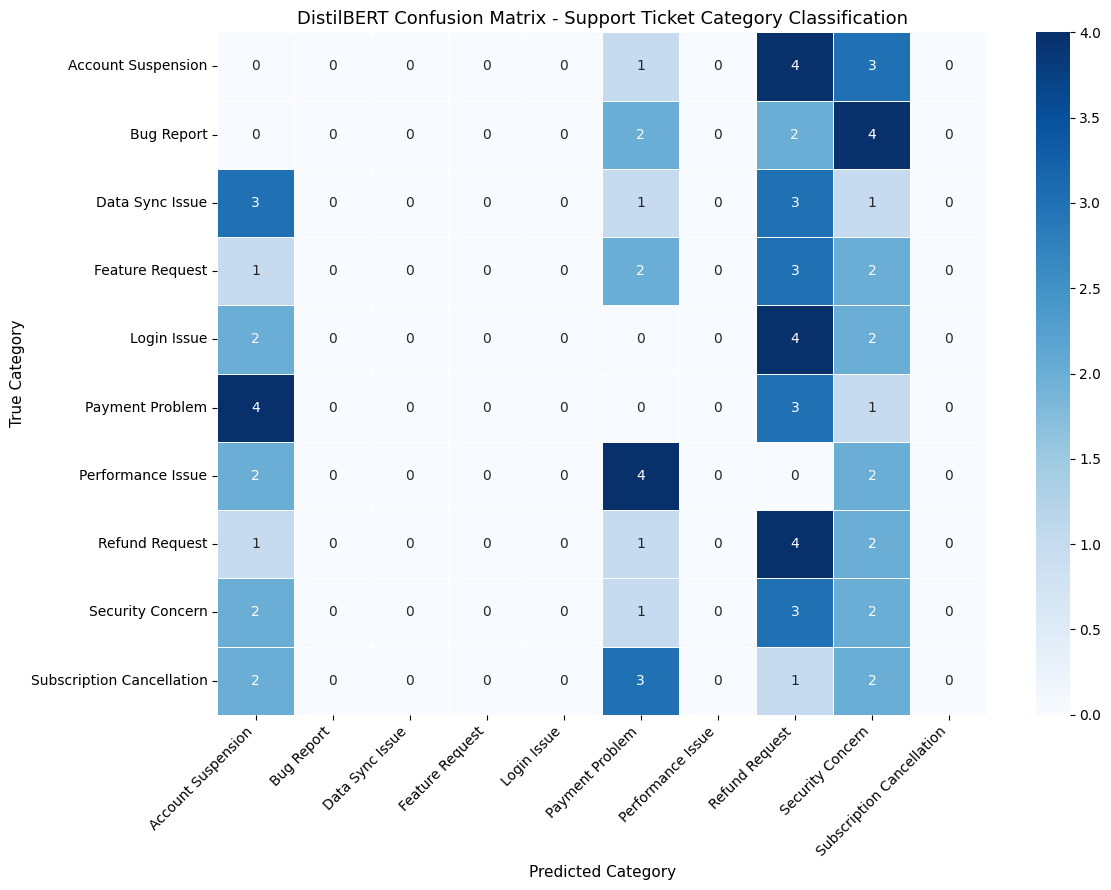

In [33]:
# =========================================================
# PHASE 5: TRAINING CURVE SUMMARY
# =========================================================
# Show per-epoch training history from the Trainer log.
import pandas as pd

log_history = trainer.state.log_history
records = [
    {k: v for k, v in entry.items() if k in
     ("epoch", "loss", "eval_loss", "eval_accuracy", "eval_f1_weighted", "eval_f1_macro")}
    for entry in log_history
    if "epoch" in entry
]
if records:
    history_df = pd.DataFrame(records).drop_duplicates(subset=["epoch"]).sort_values("epoch")
    print("Training History:")
    print(history_df.to_string(index=False))
else:
    print("No log history available.")


## Leakage Audit and Fix

Your current evaluation block is structurally correct **if** it uses `trainer.predict(test_dataset)`.

The bigger issue is in training configuration: you used `eval_dataset=test_dataset` together with `load_best_model_at_end=True`. That means the test set influenced model selection during training, which is a form of data leakage. The test set should be touched only once at final evaluation.

### What to fix
1. Keep the final confusion matrix/report on `test_dataset` only.
2. During training, use a separate validation split (from training data), not the test set.
3. Run the sanity-check cell below to verify predictions truly come from unseen test samples.

Final Test Classification Report:
                           precision    recall  f1-score   support

       Account Suspension     0.0000    0.0000    0.0000         8
               Bug Report     0.0000    0.0000    0.0000         8
          Data Sync Issue     0.0000    0.0000    0.0000         8
          Feature Request     0.0000    0.0000    0.0000         8
              Login Issue     0.0000    0.0000    0.0000         8
          Payment Problem     0.0000    0.0000    0.0000         8
        Performance Issue     0.0000    0.0000    0.0000         8
           Refund Request     0.1481    0.5000    0.2286         8
         Security Concern     0.0952    0.2500    0.1379         8
Subscription Cancellation     0.0000    0.0000    0.0000         8

                 accuracy                         0.0750        80
                macro avg     0.0243    0.0750    0.0367        80
             weighted avg     0.0243    0.0750    0.0367        80



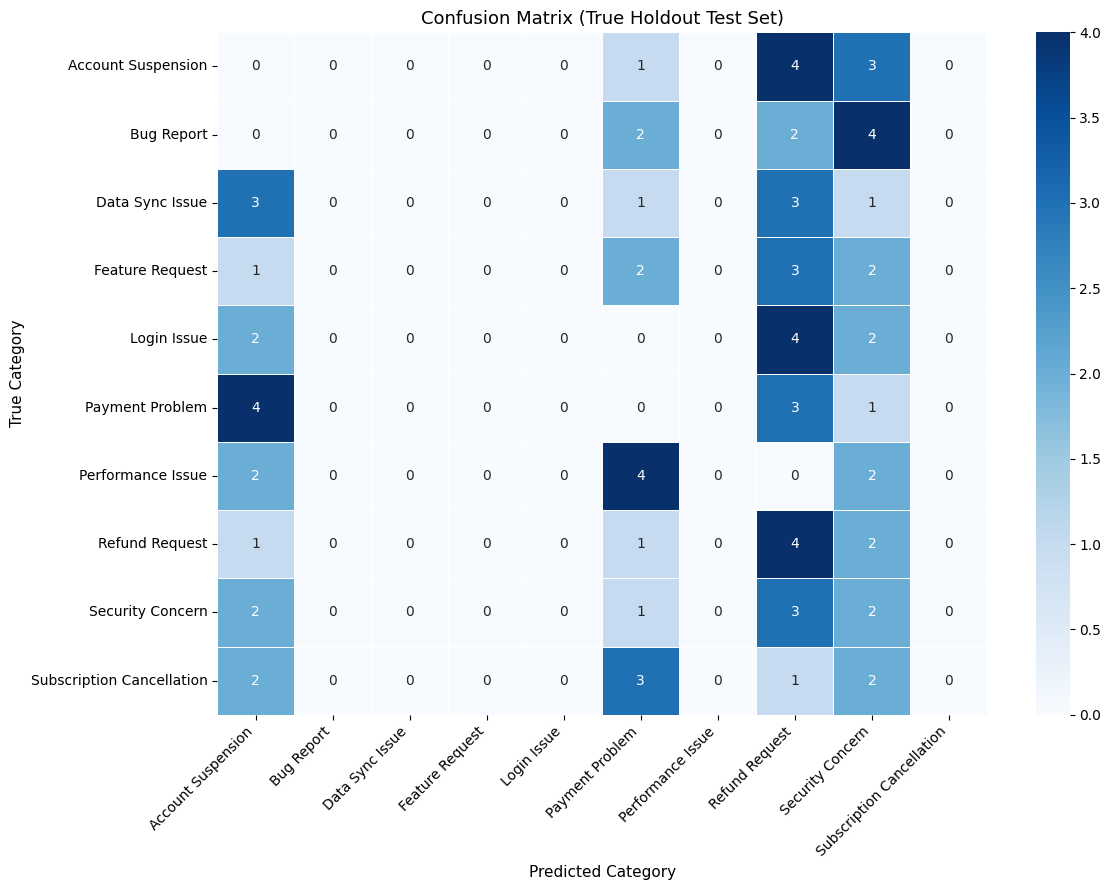

In [34]:
# =========================================================
# PHASE 5: FINAL EVALUATION ON HOLDOUT TEST SET
# =========================================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Evaluate on the UNSEEN holdout test set only.
pred_output = trainer.predict(test_dataset)
logits      = pred_output.predictions
true_labels = pred_output.label_ids
y_pred      = np.argmax(logits, axis=1)

target_names = list(category_encoder.classes_)

print("Final Test Classification Report:")
print(
    classification_report(
        true_labels, y_pred,
        target_names=target_names,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(true_labels, y_pred)
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
    linewidths=0.4,
    linecolor="white",
    ax=ax,
)
ax.set_title("Confusion Matrix – Test Holdout Set", fontsize=13)
ax.set_xlabel("Predicted Category", fontsize=11)
ax.set_ylabel("True Category", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [35]:
# =========================================================
# SANITY CHECK: INSPECT 5 RANDOM TEST SAMPLES
# =========================================================
# This cell decodes random tokenized test samples back to text and compares
# ground truth vs model prediction to quickly verify evaluation integrity.
import numpy as np
import torch

rng = np.random.default_rng(42)
sample_size = min(5, len(test_dataset))
random_indices = rng.choice(len(test_dataset), size=sample_size, replace=False)

id_to_label = {idx: name for idx, name in enumerate(category_encoder.classes_)}

print("Random Test Sample Sanity Check")
print("=" * 80)

for i, idx in enumerate(random_indices, start=1):
    sample = test_dataset[idx]

    # Decode token IDs back into readable text for manual inspection.
    decoded_text = tokenizer.decode(sample["input_ids"], skip_special_tokens=True)

    # Predict on a single-sample batch.
    with torch.no_grad():
        outputs = trainer.model(
            input_ids=sample["input_ids"].unsqueeze(0).to(trainer.model.device),
            attention_mask=sample["attention_mask"].unsqueeze(0).to(trainer.model.device),
        )
        pred_id = int(outputs.logits.argmax(dim=-1).cpu().item())

    true_id = int(sample["labels"].item())

    print(f"Sample #{i} (test index: {idx})")
    print(f"Text             : {decoded_text}")
    print(f"Actual Category  : {id_to_label[true_id]}")
    print(f"Predicted Category: {id_to_label[pred_id]}")
    print("-" * 80)

Random Test Sample Sanity Check
Sample #1 (test index: 59)
Text             : there seems to be a discrepancy in my billing statement for this month.
Actual Category  : Login Issue
Predicted Category: Refund Request
--------------------------------------------------------------------------------
Sample #2 (test index: 34)
Text             : i am experiencing very slow performance while using the dashboard.
Actual Category  : Bug Report
Predicted Category: Security Concern
--------------------------------------------------------------------------------
Sample #3 (test index: 51)
Text             : the application crashes whenever i try to upload a file.
Actual Category  : Bug Report
Predicted Category: Payment Problem
--------------------------------------------------------------------------------
Sample #4 (test index: 6)
Text             : i am experiencing very slow performance while using the dashboard.
Actual Category  : Performance Issue
Predicted Category: Security Concern
------

## Phase 6: Leakage-Safe Training, Tuning, and Deployment Readiness

This section hardens the pipeline to production-grade practice:

- Split data into **train / validation / test** (no test-time leakage).
- Train on `train_dataset`, validate on `validation_dataset`, and evaluate on `test_dataset` only once at the end.
- Save both **model** and **tokenizer** for reproducible inference.
- Add a small hyperparameter search scaffold.
- Add a reusable inference function for new unseen tickets.

In [36]:
# =========================================================
# 6.1 BUILD TRAIN / VALIDATION DATASETS FROM TRAIN SPLIT (v2)
# =========================================================
# This re-runs the split + tokenization pipeline independently so Cell 11
# artefacts do not bleed into the v2 variant.

from sklearn.model_selection import train_test_split

X_train_full = X_train.tolist()
y_train_full = list(y_train_cat)

X_train_sub, X_val_sub, y_train_sub, y_val_sub = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15,
    random_state=SEED,
    stratify=y_train_full,
)

train_sub_encodings = tokenizer(X_train_sub, truncation=True, padding=False, max_length=MAX_LENGTH)
val_sub_encodings   = tokenizer(X_val_sub,   truncation=True, padding=False, max_length=MAX_LENGTH)

train_dataset_v2   = SupportTicketDataset(train_sub_encodings, y_train_sub)
validation_dataset = SupportTicketDataset(val_sub_encodings,   y_val_sub)

print(f"Train v2 size      : {len(train_dataset_v2)}")
print(f"Validation size    : {len(validation_dataset)}")
print(f"Holdout test size  : {len(test_dataset)}")


Train v2 size      : 256
Validation size    : 64
Holdout test size  : 80


In [37]:
# =========================================================
# 6.2 LEAKAGE-SAFE TRAINING v2 (production-ready)
# =========================================================
import inspect
import torch
import torch.nn as nn
from transformers import (
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from sklearn.metrics import accuracy_score, f1_score

num_labels = len(category_encoder.classes_)

model_v2 = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
)


class WeightedTrainer(Trainer):
    """Trainer with per-class weighted cross-entropy loss."""
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weight_tensor = torch.tensor(
            [self._class_weights[i] for i in range(len(self._class_weights))],
            dtype=torch.float,
            device=logits.device,
        )
        loss = nn.CrossEntropyLoss(weight=weight_tensor)(logits, labels)
        return (loss, outputs) if return_outputs else loss


def compute_metrics_v2(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy":    accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "f1_macro":    f1_score(labels, preds, average="macro"),
    }


supported_args = set(inspect.signature(TrainingArguments.__init__).parameters)
training_kwargs = {
    "output_dir":                    "./distilbert_ticket_results_v2",
    "num_train_epochs":              5,
    "per_device_train_batch_size":   32,
    "per_device_eval_batch_size":    64,
    "learning_rate":                 3e-5,
    "weight_decay":                  0.01,
    "warmup_ratio":                  0.06,
    "save_strategy":                 "epoch",
    "logging_strategy":              "epoch",
    "load_best_model_at_end":        True,
    "metric_for_best_model":         "f1_weighted",
    "greater_is_better":             True,
    "fp16":                          torch.cuda.is_available(),
    "dataloader_num_workers":        2,
    "report_to":                     "none",
}
if "evaluation_strategy" in supported_args:
    training_kwargs["evaluation_strategy"] = "epoch"
elif "eval_strategy" in supported_args:
    training_kwargs["eval_strategy"] = "epoch"

training_kwargs = {k: v for k, v in training_kwargs.items() if k in supported_args}

has_eval = ("evaluation_strategy" in training_kwargs or "eval_strategy" in training_kwargs)
if not has_eval:
    for k in ("load_best_model_at_end", "metric_for_best_model", "greater_is_better"):
        training_kwargs.pop(k, None)

training_args_v2 = TrainingArguments(**training_kwargs)

callbacks_v2 = [EarlyStoppingCallback(early_stopping_patience=2)] if has_eval else []

trainer_v2 = WeightedTrainer(
    class_weights=class_weight_dict,
    model=model_v2,
    args=training_args_v2,
    train_dataset=train_dataset_v2,
    eval_dataset=validation_dataset,
    compute_metrics=compute_metrics_v2,
    data_collator=data_collator,
    callbacks=callbacks_v2,
)

trainer_v2.train()

final_model_dir = "./distilbert_ticket_triage_v2"
trainer_v2.save_model(final_model_dir)
tokenizer.save_pretrained(final_model_dir)
print(f"Saved model + tokenizer to: {final_model_dir}")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,2.317000,2.313403,0.078125,0.032552
2,2.300300,2.319334,0.078125,0.032552
3,2.300000,2.322491,0.046875,0.028445


Saved model + tokenizer to: ./distilbert_ticket_triage_v2


In [38]:
# =========================================================
# 6.4 INFERENCE HELPER FOR NEW UNSEEN TICKETS
# =========================================================
import torch
import numpy as np


def predict_ticket_category(
    text: str,
    model=None,
    tokenizer_obj=None,
    label_encoder=None,
    max_length: int = MAX_LENGTH,
    top_k: int = 3,
):
    """
    Predict ticket category for a single raw support-ticket string.

    Parameters
    ----------
    text         : Raw ticket text (will be cleaned automatically).
    model        : Fine-tuned DistilBERT model (defaults to trainer_v2.model).
    tokenizer_obj: Tokenizer (defaults to global `tokenizer`).
    label_encoder: LabelEncoder (defaults to global `category_encoder`).
    max_length   : Token truncation length.
    top_k        : Number of top-scoring classes to return.

    Returns
    -------
    dict with predicted_label, confidence, and top_k class probabilities.
    """
    if model is None:
        model = trainer_v2.model if "trainer_v2" in globals() else trainer.model
    if tokenizer_obj is None:
        tokenizer_obj = tokenizer
    if label_encoder is None:
        label_encoder = category_encoder

    # Apply the same text normalization used during training.
    cleaned = clean_ticket_text(text)

    model.eval()
    encoded = tokenizer_obj(
        [cleaned],
        truncation=True,
        padding=True,
        max_length=max_length,
        return_tensors="pt",
    )
    encoded = {k: v.to(model.device) for k, v in encoded.items()}

    with torch.no_grad():
        outputs = model(**encoded)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()[0]

    pred_id    = int(np.argmax(probs))
    pred_label = label_encoder.inverse_transform([pred_id])[0]
    confidence = float(probs[pred_id])

    # Top-k classes sorted by probability (descending)
    top_indices = np.argsort(probs)[::-1][:top_k]
    top_k_probs = {
        label_encoder.inverse_transform([i])[0]: round(float(probs[i]), 4)
        for i in top_indices
    }

    return {
        "predicted_label": pred_label,
        "predicted_id":    pred_id,
        "confidence":      round(confidence, 4),
        f"top_{top_k}_probabilities": top_k_probs,
    }


# Example usage
example_text = "My account keeps logging me out and I cannot access billing settings."
print(predict_ticket_category(example_text))


{'predicted_label': 'Subscription Cancellation', 'predicted_id': 9, 'confidence': 0.10849762707948685, 'class_probabilities': {'Account Suspension': 0.09410330653190613, 'Bug Report': 0.10058894753456116, 'Data Sync Issue': 0.08953364193439484, 'Feature Request': 0.10464748740196228, 'Login Issue': 0.10229727625846863, 'Payment Problem': 0.10848221182823181, 'Performance Issue': 0.09595755487680435, 'Refund Request': 0.1026172786951065, 'Security Concern': 0.09327469766139984, 'Subscription Cancellation': 0.10849762707948685}}
